In [ ]:
# !pip install -q pandas numpy matplotlib seaborn textblob itables


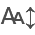

(None,
 Index(['name', 'age', 'gender', 'location', 'year',
        'Were you able to vote in the recent Lok Sabha election?',
        'When did you decide whom to vote for?',
        'What mattered more to you in this election – party or candidate?',
        'Which party do you prefer overall?',
        'Did you vote for this party because you really wanted to or due to lack of alternatives?',
        'Whose opinion mattered the most while deciding whom to vote for?',
        'Why were you not able to vote in the recent Lok Sabha election?',
        'How interested were you in the election campaign this time?',
        'Were you or a family member contacted by political parties through phone or social media?',
        'As compared to five years ago, how is the economic condition of your household today?',
        'Rate the effectiveness of the recent government policies (1 to 5)',
        'What is your top issue for this election?',
        'Do you think the government is handling inf

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from textblob import TextBlob
from itables import init_notebook_mode
from itables import show
init_notebook_mode(all_interactive=True)

# Load the uploaded dataset
file_path = 'dummy_survey_data_with_timeline.csv'
data = pd.read_csv(file_path)

# Preview the data to understand its structure
show(data.head(20)), data.columns


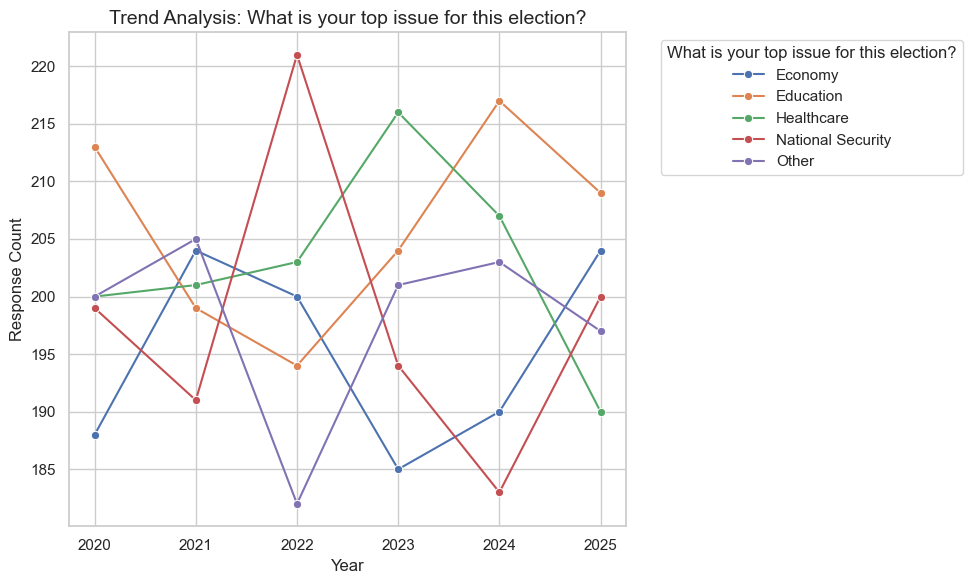

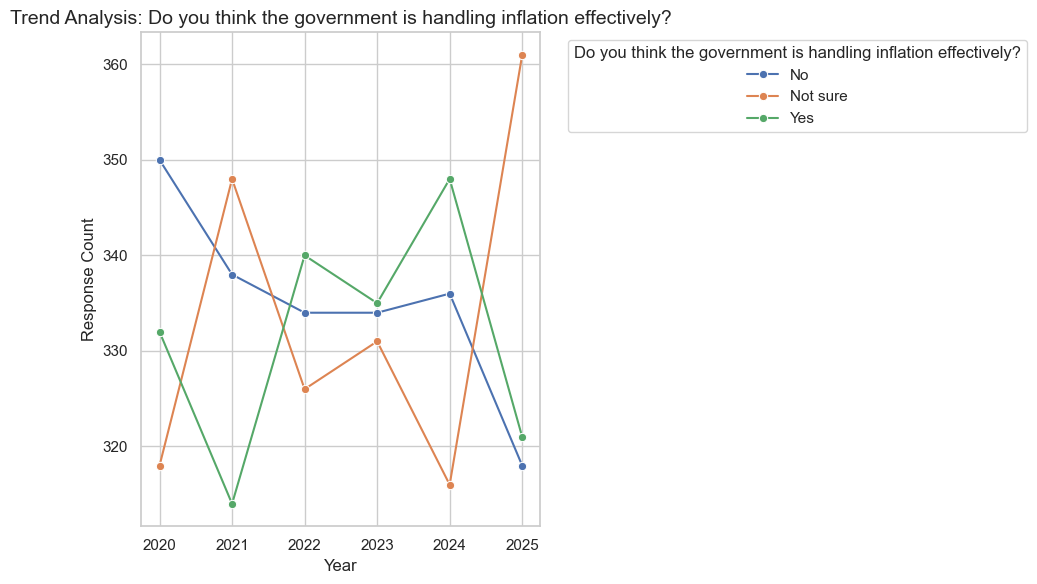

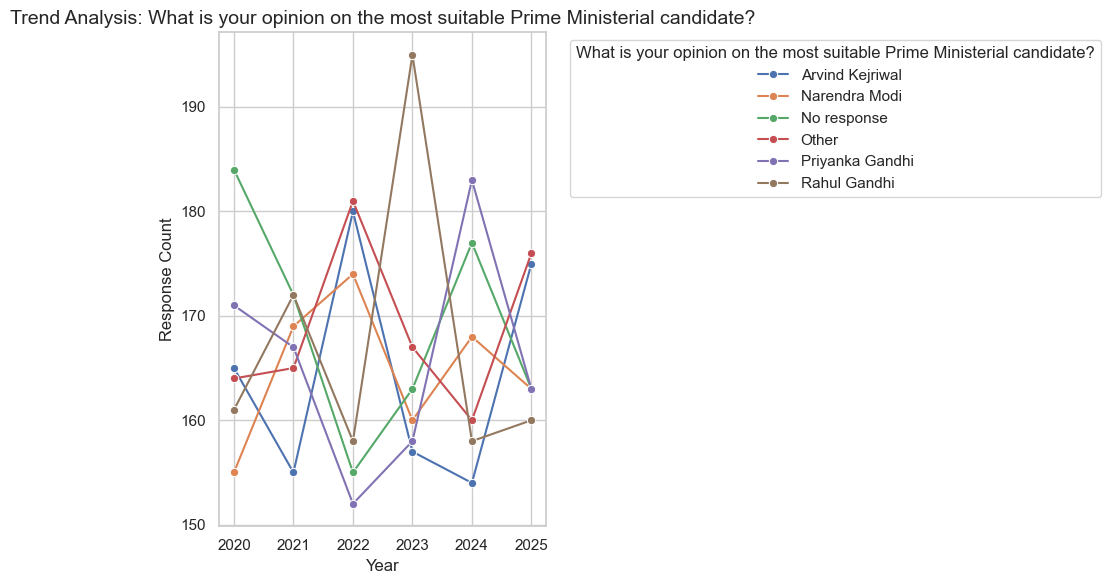

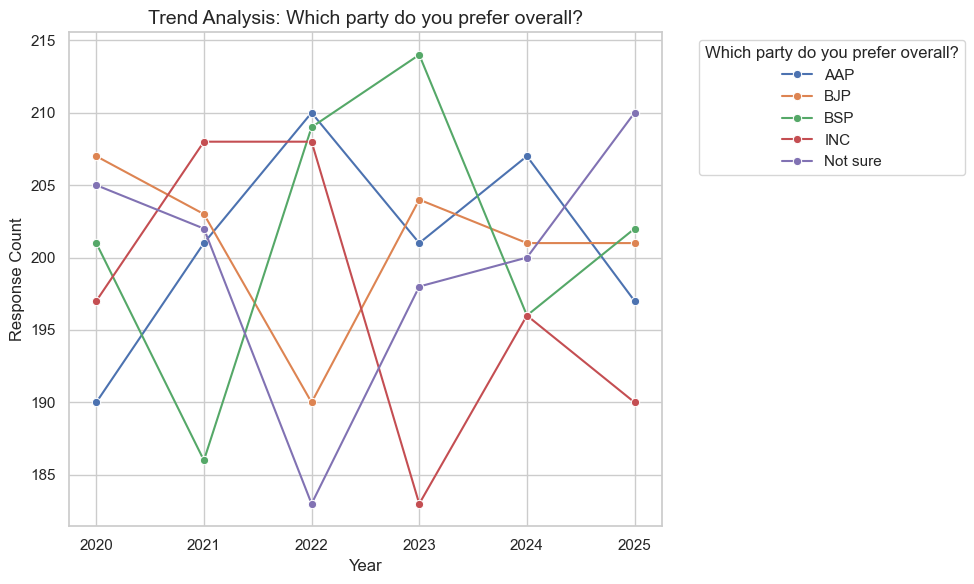

In [10]:
# Prepare data for trend analysis

# Key questions for trend analysis
key_trend_questions = [
    "What is your top issue for this election?",
    'Do you think the government is handling inflation effectively?',
    "What is your opinion on the most suitable Prime Ministerial candidate?",
    "Which party do you prefer overall?"
]

# Plot trends for each key question
# sns.set(style="whitegrid")
for question in key_trend_questions:
    plt.figure(figsize=(10, 6))
    trend_data = data.groupby(["year", question]).size().reset_index(name="count")
    sns.lineplot(data=trend_data, x="year", y="count", hue=question, marker="o")
    plt.title(f"Trend Analysis: {question}", fontsize=14)
    plt.xlabel("Year", fontsize=12)
    plt.ylabel("Response Count", fontsize=12)
    plt.xticks(data['year'].unique())
    plt.legend(title=question, bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()


In [11]:
# Prepare data for ranked insights
key_ranking_questions = [
    "What is your opinion on the most suitable Prime Ministerial candidate?",
    "Which party do you prefer overall?",
    "What is your top issue for this election?"
]

# Ranked Insights: Aggregate and sort response counts
ranked_insights = {}
for question in key_ranking_questions:
    ranking = data[question].value_counts().reset_index()
    ranking.columns = [question, "count"]
    ranking["rank"] = ranking["count"].rank(method="dense", ascending=False).astype(int)
    ranked_insights[question] = ranking

# Display Ranked Insights
for question, ranking in ranked_insights.items():
    print(f"\nRanked Insights for: {question}\n")
    show(ranking)



Ranked Insights for: What is your opinion on the most suitable Prime Ministerial candidate?




Ranked Insights for: Which party do you prefer overall?




Ranked Insights for: What is your top issue for this election?



In [12]:
# Combine non-free-text columns into a single textual representation for sentiment analysis
textual_columns = [
    "What is your top issue for this election?",
    "What is your opinion on the most suitable Prime Ministerial candidate?",
    "Which party do you prefer overall?",
    "Do you think the government is handling inflation effectively?",
    "Has your trust in the judiciary improved over the last five years?"
]

# Combine responses into a single column for sentiment analysis
data["combined_text"] = data[textual_columns].apply(lambda row: " | ".join(row.values.astype(str)), axis=1)

# Perform sentiment analysis on the combined column
data["polarity"] = data["combined_text"].apply(lambda text: TextBlob(text).sentiment.polarity)
data["subjectivity"] = data["combined_text"].apply(lambda text: TextBlob(text).sentiment.subjectivity)

# Summarize sentiment analysis results
avg_polarity_combined = data["polarity"].mean()
avg_subjectivity_combined = data["subjectivity"].mean()

# Categorize sentiments
data["sentiment_category"] = data["polarity"].apply(
    lambda x: "Positive" if x > 0 else ("Negative" if x < 0 else "Neutral")
)

# Count sentiment categories
sentiment_counts_combined = data["sentiment_category"].value_counts()

sentiment_summary_combined = {
    "Average Polarity": avg_polarity_combined,
    "Average Subjectivity": avg_subjectivity_combined,
    "Sentiment Counts": sentiment_counts_combined.to_dict(),
}

sentiment_summary_combined


{'Average Polarity': np.float64(-0.12861805555555555),
 'Average Subjectivity': np.float64(0.4396195987654321),
 'Sentiment Counts': {'Negative': 3851, 'Neutral': 2149}}